In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

dff = pd.read_csv('Flight_Delays_50K_cleaned.csv', parse_dates=['FLIGHT_DATE'])
print(dff.shape)

(50000, 35)


In [7]:
for c in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'CANCELLATION_REASON', 'TAIL_NUMBER',
          'ORIGIN_CODE_FORMAT', 'DEST_CODE_FORMAT']:
    dff[c] = dff[c].astype('category')

dff.dtypes

YEAR                            int64
MONTH                           int64
DAY                             int64
DAY_OF_WEEK                     int64
AIRLINE                      category
FLIGHT_NUMBER                   int64
TAIL_NUMBER                  category
ORIGIN_AIRPORT               category
DESTINATION_AIRPORT          category
SCHEDULED_DEPARTURE             int64
DEPARTURE_TIME                 object
DEPARTURE_DELAY               float64
TAXI_OUT                      float64
WHEELS_OFF                    float64
SCHEDULED_TIME                float64
ELAPSED_TIME                  float64
AIR_TIME                      float64
DISTANCE                        int64
WHEELS_ON                     float64
TAXI_IN                       float64
SCHEDULED_ARRIVAL               int64
ARRIVAL_TIME                  float64
ARRIVAL_DELAY                 float64
DIVERTED                        int64
CANCELLED                       int64
CANCELLATION_REASON          category
AIR_SYSTEM_D

In [9]:
def summarize(col):
    return (dff.groupby(col)
            .agg(flights=('FLIGHT_NUMBER', 'size'),
                 mean_arr_delay=('ARRIVAL_DELAY', 'mean'),
                 median_arr_delay=('ARRIVAL_DELAY', 'median'),
                 pct_delayed_15=('ARRIVAL_DELAY', lambda s: (s.dropna() >= 15).mean() * 100),
                 cancel_rate_pct=('CANCELLED', lambda s: s.mean() * 100))
            .round(2))

month_delay = summarize('MONTH')
dow_delay = summarize('DAY_OF_WEEK')
print(month_delay)
print(dow_delay)

       flights  mean_arr_delay  median_arr_delay  pct_delayed_15  \
MONTH                                                              
1         3942            5.76              -4.0           20.75   
2         3639            9.77              -2.0           24.13   
3         4317            4.05              -4.0           18.89   
4         4213            2.47              -5.0           16.46   
5         4236            2.85              -5.0           16.89   
6         4406            9.48              -3.0           24.86   
7         4446            5.74              -4.0           20.92   
8         4423            4.26              -5.0           18.67   
9         3998           -0.57              -7.0           13.47   
10        4228           -1.30              -7.0           12.64   
11        4059            1.10              -6.0           15.37   
12        4093            4.95              -5.0           19.93   

       cancel_rate_pct  
MONTH                 

Step 9: Data Visualization

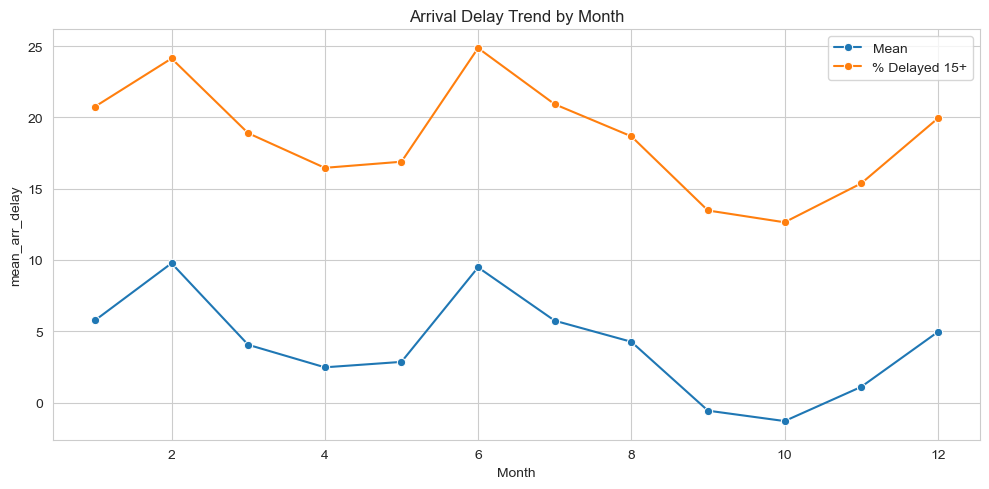

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=month_delay.index, y=month_delay['mean_arr_delay'], marker='o', label='Mean', ax=ax)
sns.lineplot(x=month_delay.index, y=month_delay['pct_delayed_15'], marker='o', label='% Delayed 15+', ax=ax)
ax.set_xlabel('Month')
ax.set_title('Arrival Delay Trend by Month')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
airline_cancel = (dff.groupby('AIRLINE', observed=True)
                  .agg(total_flights=('CANCELLED', 'size'),
                       cancelled=('CANCELLED', 'sum')))
airline_cancel['cancel_rate_%'] = (airline_cancel['cancelled'] / airline_cancel['total_flights'] * 100).round(2)
airline_cancel = airline_cancel.sort_values('cancel_rate_%', ascending=False)
airline_cancel

,total_flights,cancelled,cancel_rate_%
AIRLINE,,,
MQ,2559,131,5.12
EV,4969,150,3.02
US,1701,34,2.00
OO,4993,95,1.90
AA,6208,104,1.68
B6,2319,39,1.68
UA,4344,59,1.36
WN,10946,127,1.16
NK,990,11,1.11


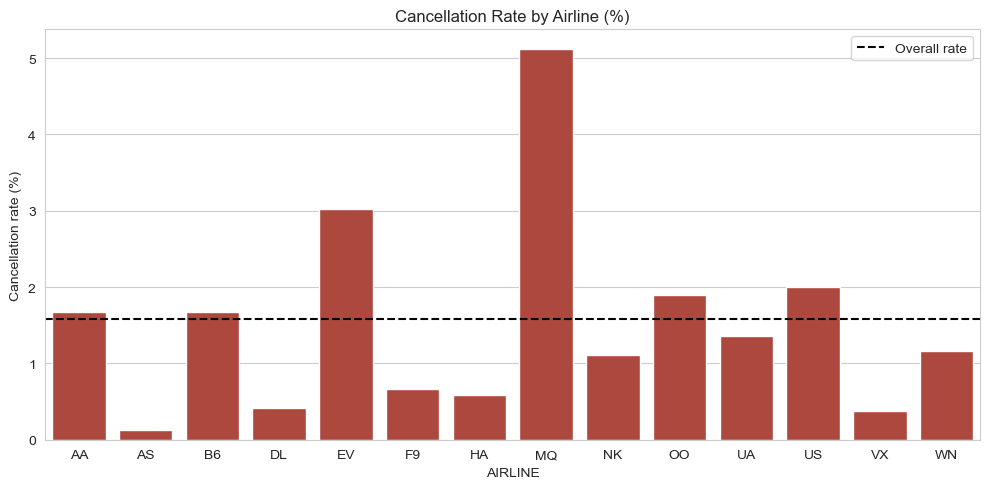

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=airline_cancel.index, y=airline_cancel['cancel_rate_%'], ax=ax, color='#c0392b')
ax.axhline(dff['CANCELLED'].mean() * 100, color='black', linestyle='--', label='Overall rate')
ax.set_title('Cancellation Rate by Airline (%)')
ax.set_ylabel('Cancellation rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

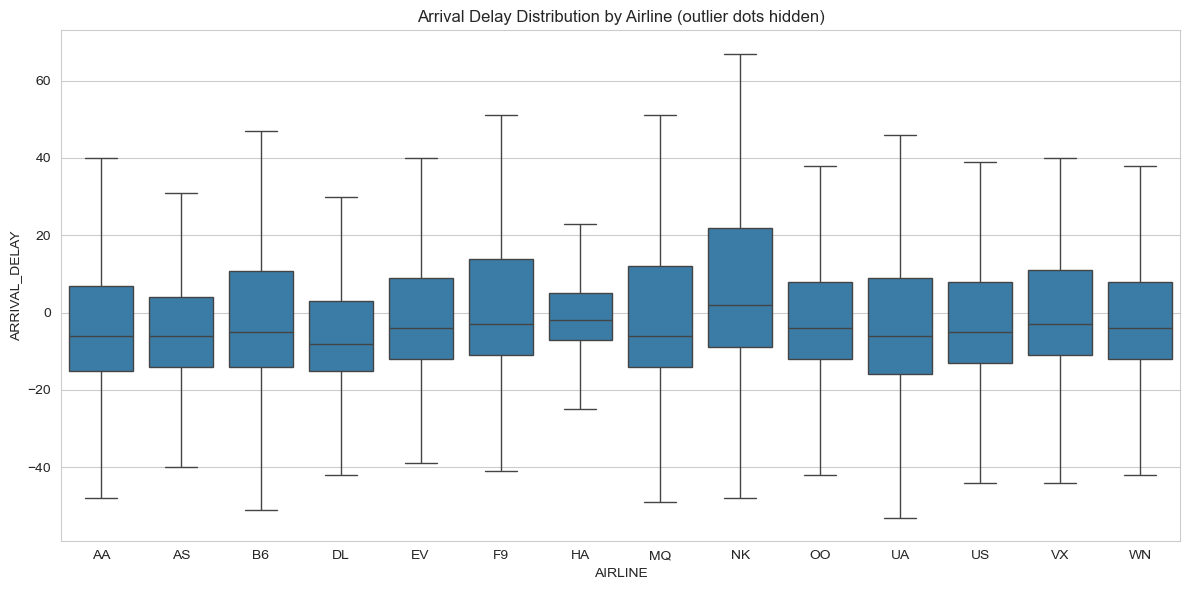

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=dff, x='AIRLINE', y='ARRIVAL_DELAY',
            showfliers=False, ax=ax, color='#2980b9')
ax.set_title('Arrival Delay Distribution by Airline (outlier dots hidden)')
plt.tight_layout()
plt.show()

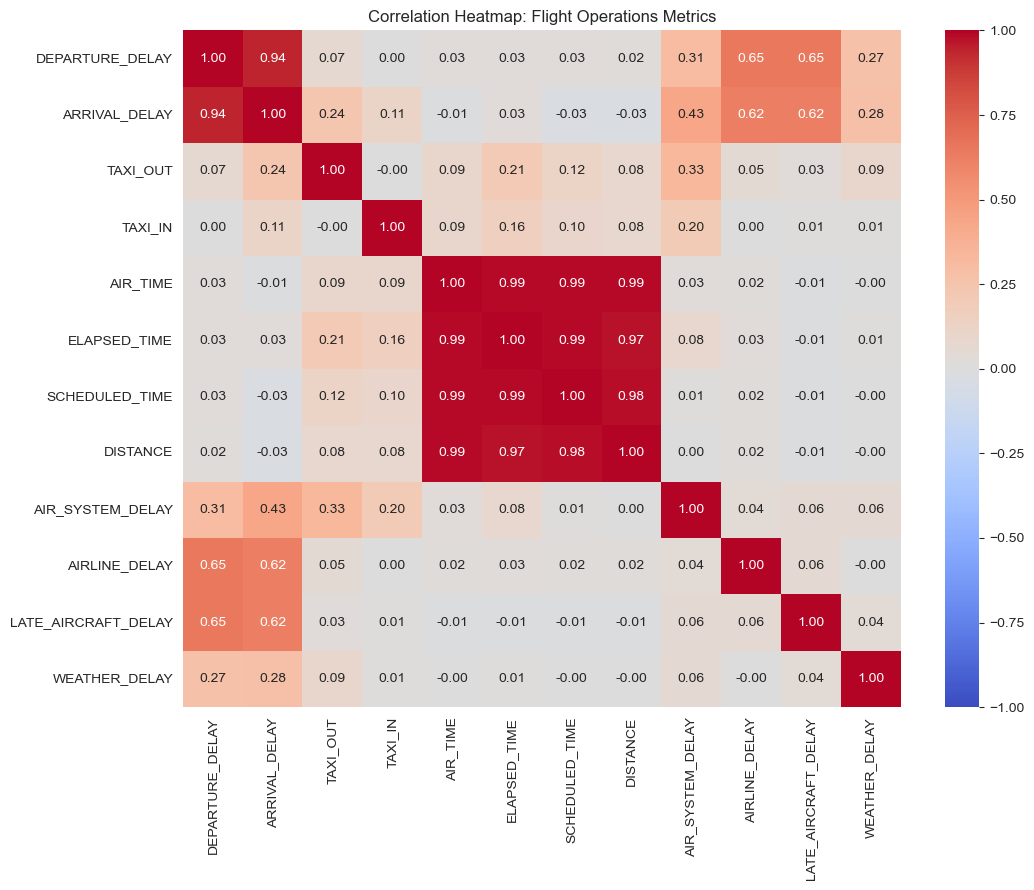

In [17]:
corr_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'TAXI_OUT', 'TAXI_IN', 'AIR_TIME',
             'ELAPSED_TIME', 'SCHEDULED_TIME', 'DISTANCE',
             'AIR_SYSTEM_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

corr_matrix = dff[corr_cols].corr(method='pearson').round(2)



plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Flight Operations Metrics')
plt.tight_layout()
plt.show()

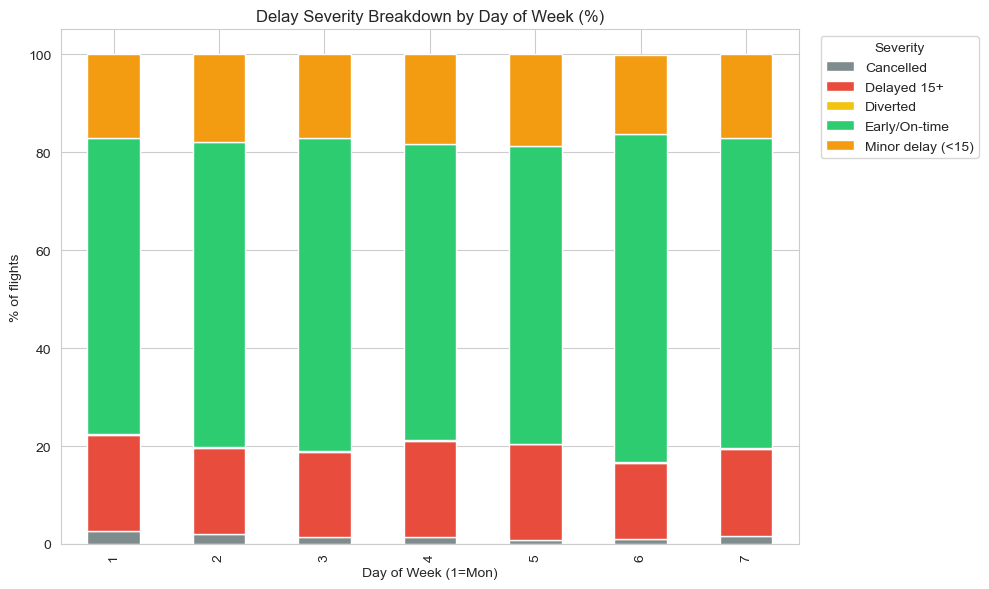

In [20]:
def severity(x):
    if pd.isna(x): return 'Cancelled/Diverted'
    if x <= 0: return 'Early/On-time'
    if x < 15: return 'Minor delay (<15)'
    return 'Delayed 15+'

dff['DELAY_SEVERITY'] = dff['ARRIVAL_DELAY'].apply(severity)
dff.loc[dff['CANCELLED'] == 1, 'DELAY_SEVERITY'] = 'Cancelled'
dff.loc[(dff['CANCELLED'] == 0) & (dff['DIVERTED'] == 1), 'DELAY_SEVERITY'] = 'Diverted'

ct = pd.crosstab(dff['DAY_OF_WEEK'], dff['DELAY_SEVERITY'], normalize='index').round(3) * 100
ct
ct.plot(kind='bar', stacked=True, figsize=(10, 6),
        color=['#7f8c8d', '#e74c3c', '#f1c40f', '#2ecc71', '#f39c12'])
plt.title('Delay Severity Breakdown by Day of Week (%)')
plt.ylabel('% of flights')
plt.xlabel('Day of Week (1=Mon)')
plt.legend(title='Severity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

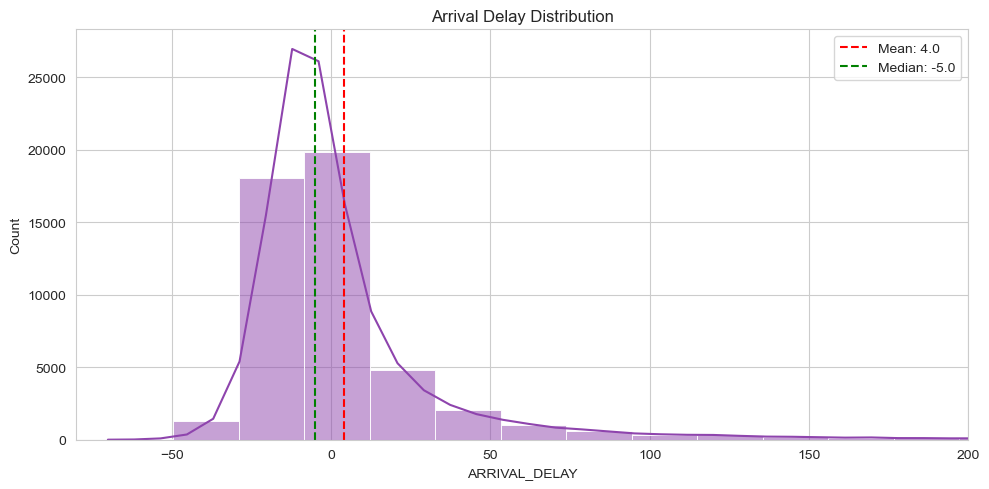

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(dff['ARRIVAL_DELAY'].dropna(), bins=80, kde=True, ax=ax, color='#8e44ad')
ax.set_xlim(-80, 200)
ax.axvline(dff['ARRIVAL_DELAY'].mean(), color='red', linestyle='--', label=f"Mean: {dff['ARRIVAL_DELAY'].mean():.1f}")
ax.axvline(dff['ARRIVAL_DELAY'].median(), color='green', linestyle='--', label=f"Median: {dff['ARRIVAL_DELAY'].median():.1f}")
ax.set_title('Arrival Delay Distribution')
ax.legend()
plt.tight_layout()
plt.show()